In [63]:
import os
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as onp

from qiskit import QuantumCircuit
from qiskit_ionq import IonQProvider

from qiskit_ibm_runtime.fake_provider import FakeLimaV2
from qiskit_aer import noise, AerSimulator

from pennylane.templates import StronglyEntanglingLayers

In [64]:
degree = 2
coeffs = [ 0.15 + 0.15j]*degree
coeff0 = 0.1

def target_function(x):
    func = coeff0
    for idx,coeff in enumerate(coeffs):
        exponent = complex(0, (idx + 1) * x) 
        func += coeff * np.exp(exponent) + np.conjugate(coeff) * np.exp(-exponent)
        
    return np.real(func)

In [65]:
n_qubits = degree
n_ansatz_layers = 2

In [66]:
def S(x):
    for w in range(n_qubits):
        qml.RY(x, wires = w)

def W(theta):
    # theta shape: (n_ansatz_layers, n_qubits, 3)
    for l in range(n_ansatz_layers):
        # single-qubit trainable rotations
        for w in range(n_qubits):
            qml.Rot(theta[l, w, 0], theta[l, w, 1], theta[l, w, 2], wires=w)

        # simple entangler
        for w in range(n_qubits - 1):
            qml.CNOT(wires=[w, w + 1])

In [67]:
def square_loss(y, predictions):
    return np.mean((y - predictions) ** 2)

def cost(params, x, y):
    predictions = circuit_parallel(params, x)   # x can now be a whole batch
    return square_loss(y, predictions)


## DEVICE FOR IONQ NOISY SIMULATIONS

In [68]:
#provider = IonQProvider(token = "MkU7QmnnoPUCcmylhNo9pPgiGqrEJL2E")

In [69]:
#noisy_backend = provider.get_backend("ionq_simulator")
#noisy_backend.set_options(noise_model="aria-1")

In [70]:
#dev = qml.device('qiskit.remote', wires=n_qubits, backend=noisy_backend)

## DEVICE FOR IBM NOISY SIMULATIONS

In [71]:
fake_backend = FakeLimaV2()
noise_model = noise.NoiseModel.from_backend(fake_backend)

aer_backend = AerSimulator()

In [72]:



dev = qml.device("qiskit.aer", wires = n_qubits, backend = aer_backend, noise_model = noise_model)
@qml.set_shots(500)
#@qml.batch_input(argnum = n_ansatz_layers * n_qubits * 3)
@qml.qnode(dev)

def circuit_parallel(params, x):
    W(params[0])
    S(x)
    W(params[1])
    return qml.expval(qml.PauliZ(0))
    
    



In [73]:
X = onp.array(np.linspace(-6, 6, 70))

target_y = onp.array([target_function(x) for x in X])

In [74]:
params_parallel = np.array(2 * np.pi * onp.random.random( size = (2, n_ansatz_layers, n_qubits, 3)), requires_grad=True)
print(params_parallel)

[[[[2.57531183 3.42366143 0.57172073]
   [5.23002075 0.59506784 5.23999784]]

  [[6.17761802 5.56682476 1.8175011 ]
   [0.52659979 4.56109084 2.50451489]]]


 [[[5.80225687 2.52955818 1.40854652]
   [5.27778392 1.55237046 6.0317731 ]]

  [[2.26270302 1.60766862 5.75311051]
   [6.24885774 3.2916655  2.65146233]]]]


(<Figure size 1200x300 with 1 Axes>, <Axes: >)

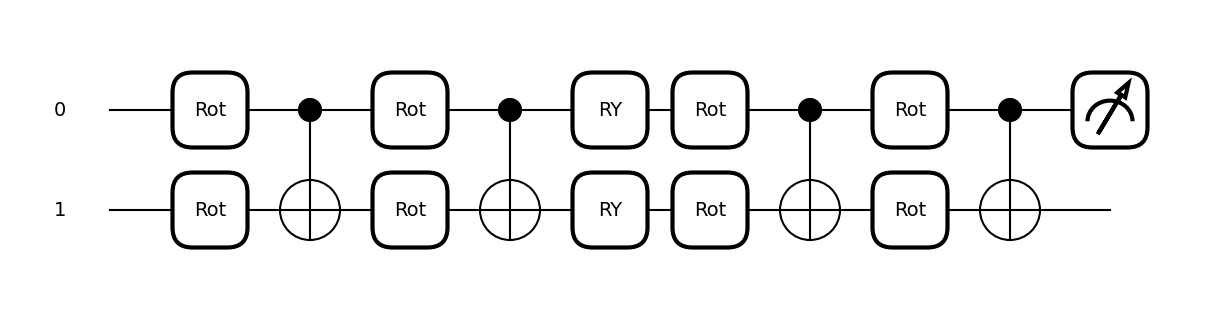

In [75]:
x1 = 0.5
qml.draw_mpl(circuit_parallel)(params_parallel, x=x1)

In [76]:


cst = [cost(params_parallel, X, target_y)]

opt = qml.SPSAOptimizer(
    maxiter = 100,
    a = 0.2,
    c = 0.05,
    alpha = 0.602,
    gamma = 0.101
)
n_iter = 200
batch_size = 20

save_path = "training_log_2qubit_ibm_spsa.npz"

for steps in range(n_iter):
    batch_index = np.random.randint(0, len(X), (batch_size,))
    x_batch = X[batch_index]
    y_batch = target_y[batch_index]

    params_parallel = opt.step(lambda p: cost(p, x_batch, y_batch), params_parallel)

    

    if (steps + 1) % 5 == 0:
        
        c = cost(params_parallel, X, target_y)
        cst.append(c)
        print( "Cost at step {0:3}: {1}".format(steps+1, c))
    
        np.savez(
            save_path,
            params = params_parallel,
            cost_history = np.array(cst),
            step = steps+1
        )

Cost at step   5: 0.34841557865088557
Cost at step  10: 0.3141867249548692
Cost at step  15: 0.2958695659547414
Cost at step  20: 0.2802634035434656
Cost at step  25: 0.26021503787588485
Cost at step  30: 0.20925781965674298
Cost at step  35: 0.20752973021502583
Cost at step  40: 0.19179265782118543
Cost at step  45: 0.17055798908908515
Cost at step  50: 0.15388047366422375
Cost at step  55: 0.14817349321787185
Cost at step  60: 0.13786227149705163
Cost at step  65: 0.12857086719080324
Cost at step  70: 0.11317144264239176
Cost at step  75: 0.09401983484970185
Cost at step  80: 0.09273014421949244
Cost at step  85: 0.0820882215815014
Cost at step  90: 0.08162681066567731
Cost at step  95: 0.06362043917002234
Cost at step 100: 0.05959474818984082
Cost at step 105: 0.05766392106814436
Cost at step 110: 0.05197662780323598
Cost at step 115: 0.055104505524332714
Cost at step 120: 0.04607501070281164
Cost at step 125: 0.04899680005557645
Cost at step 130: 0.042688290751225696
Cost at step 1

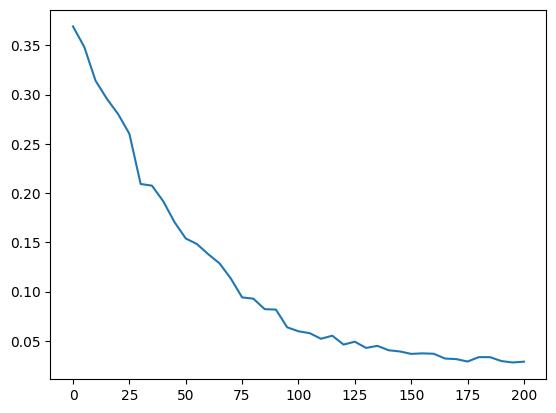

In [84]:
plt.plot(range(0,n_iter+1,5), cst)

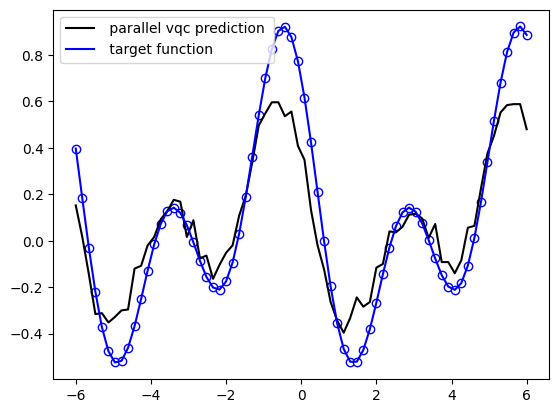

In [78]:
preds = [ circuit_parallel( params_parallel, x) for x in X]

plt.plot(X, preds, label = " parallel vqc prediction ",  c = 'black')
plt.plot(X, target_y, label = " target function ", c = "blue")
plt.scatter(X, target_y, facecolor = 'white', edgecolor = 'blue' )
plt.legend()